In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Semilla para reproducibilidad (que los datos random sean siempre iguales)
np.random.seed(42)

# Generamos el dataset de ventas
n = 500  # 500 transacciones

clientes = ['Ana Torres', 'Carlos Ruiz', 'María López', 'Diego Hernández',
            'Sofía Martínez', 'Luis González', 'Valentina Cruz', 'Andrés Morales',
            'Camila Reyes', 'Javier Ortiz']

productos = ['Laptop', 'Mouse', 'Teclado', 'Monitor', 'Audífonos',
             'Webcam', 'USB Hub', 'Silla ergonómica', 'Escritorio', 'Lámpara LED']

precios = {
    'Laptop': 18000, 'Mouse': 350, 'Teclado': 800, 'Monitor': 6500,
    'Audífonos': 1200, 'Webcam': 900, 'USB Hub': 450,
    'Silla ergonómica': 4500, 'Escritorio': 7000, 'Lámpara LED': 600
}

fechas = pd.date_range(start='2024-01-01', end='2024-12-31', periods=n)
productos_vendidos = np.random.choice(productos, n)
clientes_ventas = np.random.choice(clientes, n)
cantidades = np.random.randint(1, 5, n)

df = pd.DataFrame({
    'fecha': fechas,
    'cliente': clientes_ventas,
    'producto': productos_vendidos,
    'cantidad': cantidades,
    'precio_unitario': [precios[p] for p in productos_vendidos]
})

# Columna calculada: ingreso total por transacción
df['ingreso'] = df['precio_unitario'] * df['cantidad']

# Introducimos algunos datos sucios a propósito
df.loc[10, 'cantidad'] = -1      # cantidad negativa (error)
df.loc[50, 'precio_unitario'] = 0  # precio en cero (error)
df.loc[100, 'ingreso'] = np.nan   # ingreso faltante

df.head()

,fecha,cliente,producto,cantidad,precio_unitario,ingreso
0,2024-01-01 00:00:00.000000,Camila Reyes,USB Hub,1,450,450.0
1,2024-01-01 17:33:18.396793,Ana Torres,Monitor,3,6500,19500.0
2,2024-01-02 11:06:36.793587,Ana Torres,Silla ergonómica,4,4500,18000.0
3,2024-01-03 04:39:55.190380,Diego Hernández,Audífonos,4,1200,4800.0
4,2024-01-03 22:13:13.587174,Camila Reyes,USB Hub,3,450,1350.0


In [2]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.describe()

(500, 6)
fecha              datetime64[us]
cliente                       str
producto                      str
cantidad                    int64
precio_unitario             int64
ingreso                   float64
dtype: object
fecha              0
cliente            0
producto           0
cantidad           0
precio_unitario    0
ingreso            1
dtype: int64


,fecha,cantidad,precio_unitario,ingreso
count,500,500.000000,500.000000,499.000000
mean,2024-07-01 11:59:59.999999,2.440000,4351.400000,10401.102204
min,2024-01-01 00:00:00,-1.000000,0.000000,350.000000
25%,2024-04-01 05:59:59.999999,1.000000,600.000000,1350.000000
50%,2024-07-01 11:59:59.999999,2.000000,1200.000000,2700.000000
75%,2024-09-30 17:59:59.999999,3.000000,6500.000000,18000.000000
max,2024-12-31 00:00:00,4.000000,18000.000000,72000.000000
std,NaN,1.108539,5664.465587,14867.434082


In [3]:
# Error 1: eliminamos filas con cantidad negativa o cero
df = df[df['cantidad'] > 0]

# Error 2: eliminamos filas con precio_unitario igual a cero
df = df[df['precio_unitario'] > 0]

# Error 3: rellenamos el ingreso faltante con precio * cantidad
df['ingreso'] = df['precio_unitario'] * df['cantidad']

# Verificamos que quedó limpio
print(df.shape)
print(df.isnull().sum())
print(f"Cantidad mínima: {df['cantidad'].min()}")
print(f"Precio mínimo: {df['precio_unitario'].min()}")

(498, 6)
fecha              0
cliente            0
producto           0
cantidad           0
precio_unitario    0
ingreso            0
dtype: int64
Cantidad mínima: 1
Precio mínimo: 350


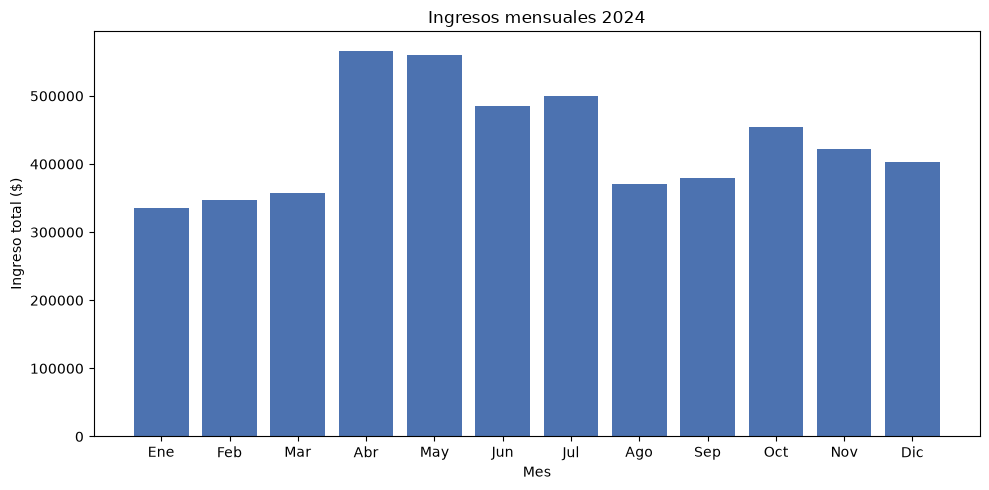

In [4]:
# Extraemos el mes
df['mes'] = df['fecha'].dt.month

# Agrupamos y graficamos
ventas_mes = df.groupby('mes')['ingreso'].sum()
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(10, 5))
plt.bar(meses, ventas_mes.values, color='#4C72B0')
plt.title('Ingresos mensuales 2024')
plt.xlabel('Mes')
plt.ylabel('Ingreso total ($)')
plt.tight_layout()
plt.show()

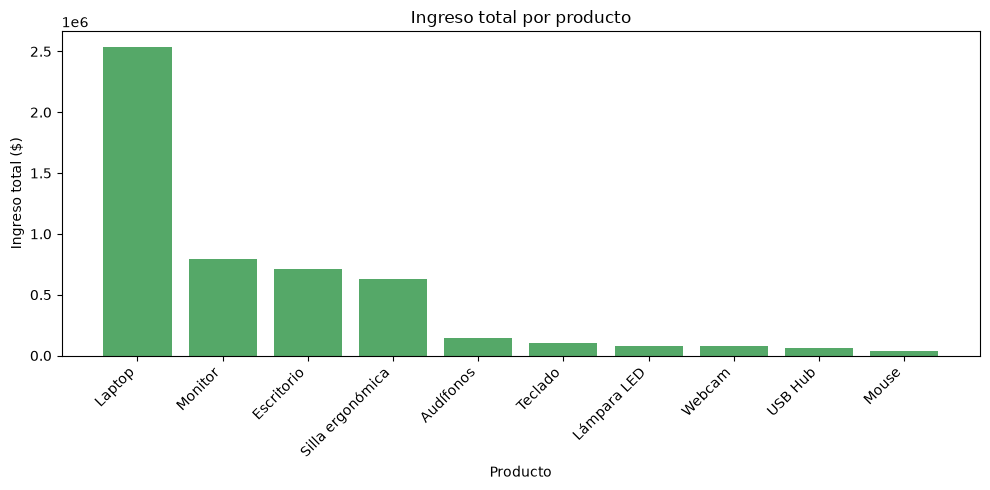

In [6]:
productos_top = df.groupby('producto')['ingreso'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(productos_top.index, productos_top.values, color='#55A868')
plt.title('Ingreso total por producto')
plt.xlabel('Producto')
plt.ylabel('Ingreso total ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

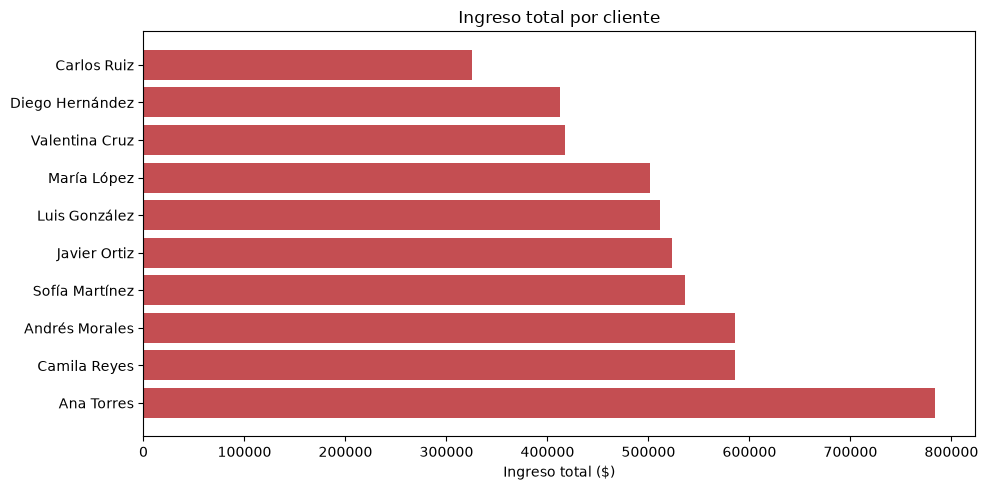

In [7]:
clientes_top = df.groupby('cliente')['ingreso'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(clientes_top.index, clientes_top.values, color='#C44E52')
plt.title('Ingreso total por cliente')
plt.xlabel('Ingreso total ($)')
plt.tight_layout()
plt.show()

In [8]:
# Comparamos unidades vendidas vs ingreso por producto
resumen_productos = df.groupby('producto').agg(
    unidades=('cantidad', 'sum'),
    ingreso_total=('ingreso', 'sum')
).sort_values('ingreso_total', ascending=False)

resumen_productos

,unidades,ingreso_total
producto,,
Laptop,141,2538000
Monitor,122,793000
Escritorio,102,714000
Silla ergonómica,140,630000
Audífonos,123,147600
Teclado,133,106400
Lámpara LED,132,79200
Webcam,85,76500
USB Hub,138,62100
